In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("sample_data (1).csv")

df.head(5)

,Unnamed: 0,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,139669,1-102-2022-15336,102,1,مبايعات,Sales,بيع - تسجيل مبدئى,Sell - Pre registration,2022-06-13,3,...,1 B/R,1,62.81,1233000.0,19630.63,NaN,NaN,1.0,1.0,0.0
1,788920,1-102-2013-7960,102,1,مبايعات,Sales,بيع - تسجيل مبدئى,Sell - Pre registration,2013-09-30,3,...,Office,1,103.63,539420.0,5205.25,NaN,NaN,1.0,1.0,0.0
2,729356,1-11-2025-24285,11,1,مبايعات,Sales,بيع,Sell,2025-06-10,3,...,1 B/R,1,56.79,890000.0,15671.77,NaN,NaN,2.0,1.0,0.0
3,1112915,1-102-2016-4650,102,1,مبايعات,Sales,بيع - تسجيل مبدئى,Sell - Pre registration,2016-04-28,3,...,Studio,1,38.10,454811.0,11937.32,NaN,NaN,1.0,1.0,0.0
4,47566,1-11-2013-33304,11,1,مبايعات,Sales,بيع,Sell,2013-11-05,3,...,1 B/R,1,97.60,9597888.0,98339.02,NaN,NaN,1.0,1.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            90000 non-null  int64  
 1   transaction_id        90000 non-null  object 
 2   procedure_id          90000 non-null  int64  
 3   trans_group_id        90000 non-null  int64  
 4   trans_group_ar        90000 non-null  object 
 5   trans_group_en        90000 non-null  object 
 6   procedure_name_ar     90000 non-null  object 
 7   procedure_name_en     90000 non-null  object 
 8   instance_date         90000 non-null  object 
 9   property_type_id      90000 non-null  int64  
 10  property_type_ar      90000 non-null  object 
 11  property_type_en      90000 non-null  object 
 12  property_sub_type_id  71812 non-null  float64
 13  property_sub_type_ar  71812 non-null  object 
 14  property_sub_type_en  71812 non-null  object 
 15  property_usage_ar  

In [4]:
df.isnull().sum()

Unnamed: 0                  0
transaction_id              0
procedure_id                0
trans_group_id              0
trans_group_ar              0
trans_group_en              0
procedure_name_ar           0
procedure_name_en           0
instance_date               0
property_type_id            0
property_type_ar            0
property_type_en            0
property_sub_type_id    18188
property_sub_type_ar    18188
property_sub_type_en    18188
property_usage_ar           0
property_usage_en           0
reg_type_id                 0
reg_type_ar                 0
reg_type_en                 0
area_id                     0
area_name_ar                0
area_name_en                0
building_name_ar        26032
building_name_en        26004
project_number          24553
project_name_ar         24553
project_name_en         24553
master_project_en       12280
master_project_ar       12280
nearest_landmark_ar     17004
nearest_landmark_en     17004
nearest_metro_ar        27003
nearest_me

In [5]:
arabic_cols = [
'trans_group_ar',
'procedure_name_ar',
'property_type_ar',
'property_sub_type_ar',
'property_usage_ar',
'reg_type_ar',
'area_name_ar',
'building_name_ar',
'project_name_ar',
'master_project_ar',
'nearest_landmark_ar',
'nearest_metro_ar',
'nearest_mall_ar',
'rooms_ar'
]

df.drop(columns=arabic_cols, inplace=True)

In [6]:
df.drop(columns=['rent_value','meter_rent_price'], inplace=True)
#dropping these columns due to excessive missing values (approx 97% is missing)

In [7]:
drop_cols = [
'Unnamed: 0',
'transaction_id',
'procedure_id',
'trans_group_id',
'property_type_id',
'area_id',
'project_number'
]

df.drop(columns=drop_cols, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trans_group_en        90000 non-null  object 
 1   procedure_name_en     90000 non-null  object 
 2   instance_date         90000 non-null  object 
 3   property_type_en      90000 non-null  object 
 4   property_sub_type_id  71812 non-null  float64
 5   property_sub_type_en  71812 non-null  object 
 6   property_usage_en     90000 non-null  object 
 7   reg_type_id           90000 non-null  int64  
 8   reg_type_en           90000 non-null  object 
 9   area_name_en          90000 non-null  object 
 10  building_name_en      63996 non-null  object 
 11  project_name_en       65447 non-null  object 
 12  master_project_en     77720 non-null  object 
 13  nearest_landmark_en   72996 non-null  object 
 14  nearest_metro_en      62997 non-null  object 
 15  nearest_mall_en    

In [9]:
df['instance_date'] = pd.to_datetime(df['instance_date'], errors='coerce')

df['year'] = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month

In [10]:
df['building_name_en'] = df['building_name_en'].fillna('Unknown')

counts = df['building_name_en'].value_counts()

df['building_name_en'] = df['building_name_en'].apply(
    lambda x: x if counts[x] >= 10 else 'Other'
)

In [11]:
cols = ['building_name_en','project_name_en','master_project_en']

for col in cols:
    df[col] = df[col].fillna('Unknown')
    counts = df[col].value_counts()
    df[col] = df[col].apply(lambda x: x if counts.get(x,0) >= 10 else 'Other')

In [12]:
X = df.drop('meter_sale_price', axis=1)
y = df['meter_sale_price']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
import category_encoders as ce

cols = ['area_name_en','building_name_en','project_name_en','master_project_en']

encoder = ce.TargetEncoder(cols=cols)

X_train = encoder.fit_transform(X_train, y_train)
X_test = encoder.transform(X_test)

In [15]:
import category_encoders as ce

cols = ['area_name_en','building_name_en','project_name_en','master_project_en']

encoder = ce.TargetEncoder(cols=cols)

X_train = encoder.fit_transform(X_train, y_train)
X_test = encoder.transform(X_test)

In [16]:
cat_cols = [
    'trans_group_en',
    'procedure_name_en',
    'property_type_en',
    'property_sub_type_en',
    'property_usage_en',
    'reg_type_en',
    'nearest_mall_en',
    'rooms_en'
]

In [17]:
for col in cat_cols:
    print(col, df[col].nunique())

trans_group_en 3
procedure_name_en 40
property_type_en 4
property_sub_type_en 15
property_usage_en 11
reg_type_en 2
nearest_mall_en 5
rooms_en 14


In [18]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [19]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

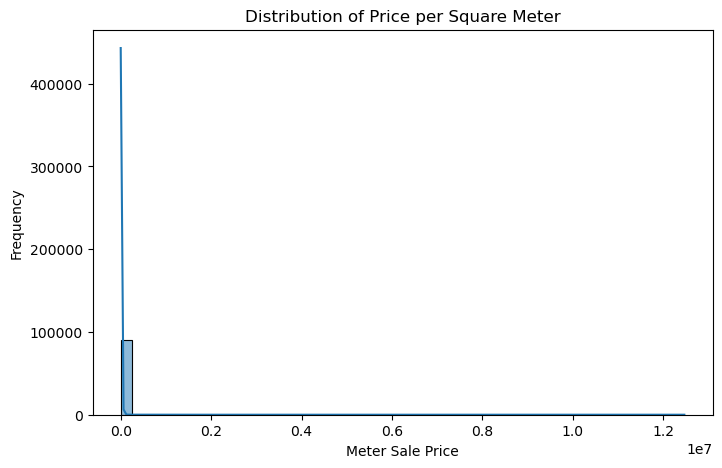

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['meter_sale_price'], bins=50, kde=True)

plt.title("Distribution of Price per Square Meter")
plt.xlabel("Meter Sale Price")
plt.ylabel("Frequency")

plt.show()

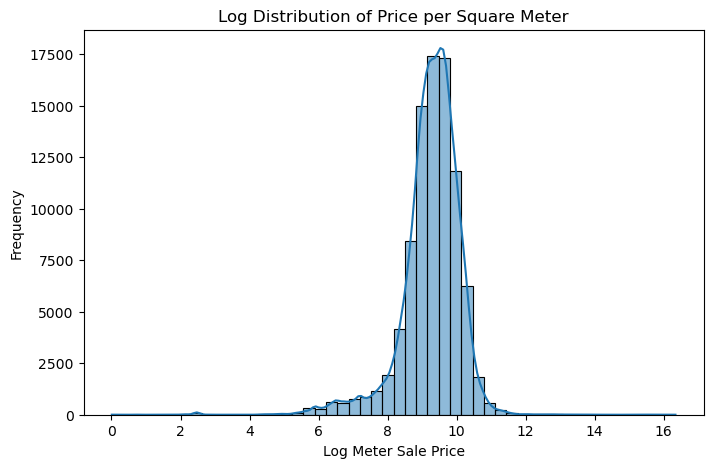

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['meter_sale_price']), bins=50, kde=True)

plt.title("Log Distribution of Price per Square Meter")
plt.xlabel("Log Meter Sale Price")
plt.ylabel("Frequency")

plt.show()

In [22]:
df['instance_date'] = pd.to_datetime(df['instance_date'])

df['day'] = df['instance_date'].dt.day
df['month'] = df['instance_date'].dt.month
df['year'] = df['instance_date'].dt.year

In [23]:
df.drop('instance_date', axis=1, inplace=True)

In [24]:
X_train = X_train.drop('instance_date', axis=1)
X_test = X_test.drop('instance_date', axis=1)

In [25]:
X_train.select_dtypes(include='object').columns

Index(['nearest_landmark_en', 'nearest_metro_en'], dtype='object')

In [26]:
extra_cols = [
    'nearest_landmark_en',
    'nearest_metro_en'
]

X_train = pd.get_dummies(X_train, columns=extra_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=extra_cols, drop_first=True)

In [27]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trans_group_en        90000 non-null  object 
 1   procedure_name_en     90000 non-null  object 
 2   property_type_en      90000 non-null  object 
 3   property_sub_type_id  71812 non-null  float64
 4   property_sub_type_en  71812 non-null  object 
 5   property_usage_en     90000 non-null  object 
 6   reg_type_id           90000 non-null  int64  
 7   reg_type_en           90000 non-null  object 
 8   area_name_en          90000 non-null  object 
 9   building_name_en      90000 non-null  object 
 10  project_name_en       90000 non-null  object 
 11  master_project_en     90000 non-null  object 
 12  nearest_landmark_en   72996 non-null  object 
 13  nearest_metro_en      62997 non-null  object 
 14  nearest_mall_en       62463 non-null  object 
 15  rooms_en           

In [29]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 8829.899639284296
RMSE: 87613.52147940043
R2 Score: 0.466769576187819


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42)

In [33]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1703.4358251228234
RMSE: 56176.98600390251
R2: 0.780775283473347


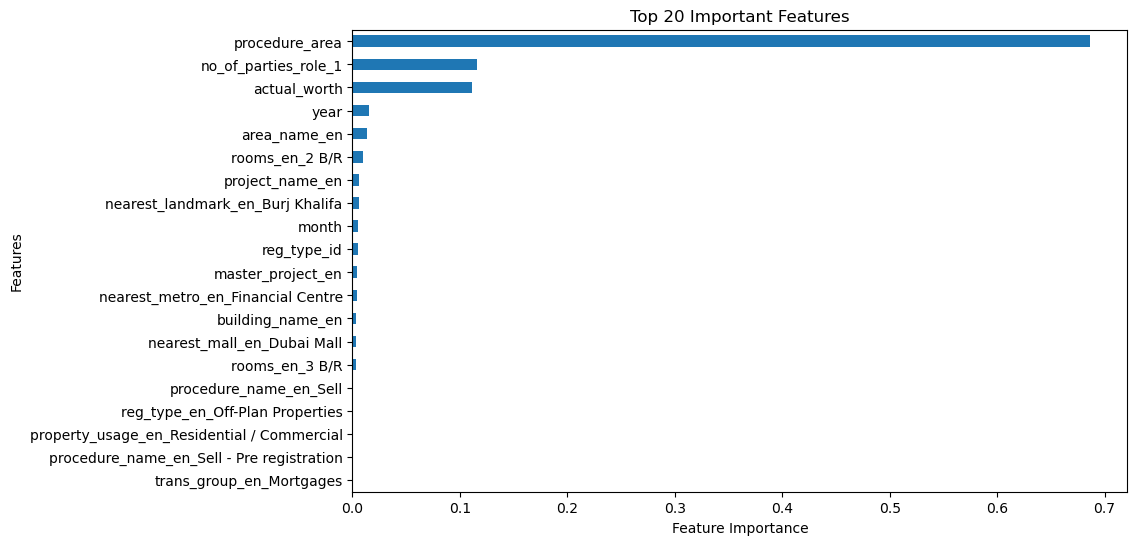

In [34]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)

top_features = importance.sort_values(ascending=False)


plt.figure(figsize=(10,6))
top_features.head(20).plot(kind='barh')

plt.title("Top 20 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()